# WP4 Annex A, Level 3: redox architecture, checked basis piece by basis piece

Level 3 of the sediment-hosted recipe generates a binary reduced-facies field at and near the basement-cover contact: a modest marginal probability of presence, about 0.1 to 0.3, with spatial structure taken from how reduced-facies belts behave in the analog basins, belts of tens of kilometres containing patches of one to ten kilometres (both marked [CHECK] in the annex). The concept places ore only where reduced rocks exist, and no published map of the era showed reduced facies in the target position, so the annex calls this level the concept's largest honest uncertainty. It closes with *"Basis: the facies descriptions in the few t0 bore logs, and the pre-1975 analog literature for the correlation structure."* Two pieces, taken one at a time:

- **Part A: the facies descriptions in the t0 bore logs.** The SA Geodata lithology and stratigraphy exports for the pre-t0 holes of the 2-degree buffer, screened for redox words with each log's own date kept; Bulletin 41 (Johns 1968); and the pre-t0 Mount Gunson reports, cut to their page ranges.
- **Part B: the pre-1975 analog literature.** Ten papers of the 1974 Liege volume *Gisements stratiformes et provinces cupriferes* (Bartholome, ed.): Kupferschiefer, Zambian Copperbelt, Shaba, northern Michigan, Permian copper shales, Canada and the Adelaidean of South Australia; and the two White Pine papers in Economic Geology, White and Wright (1954) and Brown (1971). The two books the annex names, Mendelsohn (1961) and Ensign et al. (1968), are print only and not on disk.

Each part ends with a verdict on the piece. Part C takes Mount Gunson, the analog WMC's own concept named, where both pieces meet: a dossier of what the pre-t0 reports said about its reduced host, its lengths and its ore. Part D lays the Annex A Level 3 rows against what all of this can now cite. Only files in `wp4_prior_state/annexA_levels/level3_redox_architecture/` are read. The information-state rule is one cutoff, t0 = 2 May 1975 (the EL 190 grant). Figures are drawn at final printed width and saved at 300 dpi to `03_results/wp4_prior/figures/` as `wp4_L3_<part><step>_*.png`.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

All reads are relative paths into the Level 3 folder. The facies tables were made by `level3_facies_screen.py`: every interval of a hole drilled before t0 in the 2-degree buffer, with a redox class read from the logged words only (description and lithology names, never the stratigraphic dictionary text). "Reduced" means grey, green, black or dark colours or a reductant (carbonaceous, pyrite, sulphides) with no oxidised word; "oxidised" means red, purple, brown, haematite or limonite words only; "mixed" means both; "none" means neither. The Mount Gunson dates were read from the catalogue or from the documents' own pages; the analog statements were transcribed from OCR of the Liege scans, with page numbers.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

L3 = Path("../../01_data/wp1_data/database/wp4_prior_state/annexA_levels/level3_redox_architecture")
FIG = Path("../../03_results/wp4_prior/figures")
TAB = Path("../../03_results/wp4_prior")
assert L3.is_dir(), "run from 02_code/notebooks/"
FIG.mkdir(parents=True, exist_ok=True)
BF, AL = L3 / "bore_facies_descriptions", L3 / "analog_literature"

T0 = pd.Timestamp("1975-05-02")                        # EL 190 grant: the one cutoff
OD_LON, OD_LAT = 136.887, -30.441                      # Olympic Dam (wp1_harvester OD_CENTER, GDA2020)
PIECE_COL = {1: "#2a78d6", 2: "#eda100"}               # one colour per basis piece, used in every figure
FAC_COL = {"reduced": "#2e5e4e", "mixed": "#8fb996", "oxidised": "#c0504d", "none": "#d0d0d0"}
FAC_LAB = {"reduced": "reduced words only", "mixed": "reduced and oxidised words",
           "oxidised": "oxidised words only", "none": "no redox word"}
FT_M = 0.3048
dec = lambda ts: ts.year + (ts.dayofyear - 1) / 365.25
T0Y = dec(T0)

for sub in sorted(p for p in L3.rglob("*") if p.is_dir()):
    files = [p for p in sub.iterdir() if p.is_file()]
    print(f"{str(sub.relative_to(L3)):48s} {len(files):3d} files {sum(p.stat().st_size for p in files)/1e6:7.1f} MB")

lit = pd.read_csv(BF / "sa_geodata/level3_litho_facies_intervals_pre_t0.csv", low_memory=False)
strat = pd.read_csv(BF / "sa_geodata/level3_strat_facies_intervals_pre_t0.csv", low_memory=False)
con = pd.read_csv(BF / "sa_geodata/level3_contact_intervals.csv")
win = pd.read_csv(BF / "sa_geodata/study_windows.csv").set_index("window")
mg = pd.read_csv(BF / "mount_gunson/level3_mount_gunson_subreport_dates.csv", dtype={"env": str})
dims = pd.read_csv(AL / "transcriptions/level3_analog_dimensions_pre_t0.csv")
man = pd.read_csv(AL / "analogs_manifest.csv")
b41 = (BF / "bulletin41/Bull_041_Johns_1968_text.txt").read_text(encoding="utf-8", errors="replace")
for df in (lit, strat):
    df["drill_date"] = pd.to_datetime(df.drill_date, errors="coerce")
    df["logging_date"] = pd.to_datetime(df.logging_date, errors="coerce")
lit_pre = lit[lit.logged_before_t0 == True].copy()
print(f"\nlitho intervals {len(lit)} in {lit.DRILLHOLE_NO.nunique()} holes; logged before t0: {len(lit_pre)} "
      f"in {lit_pre.DRILLHOLE_NO.nunique()} holes")
print(f"strat intervals {len(strat)} in {strat.DRILLHOLE_NO.nunique()} holes; logged before t0: "
      f"{int((strat.logged_before_t0 == True).sum())}")
print(f"contact rows: {con.groupby('reading').size().to_dict()}")
print(f"Mount Gunson sub-reports: {mg.status_t0.value_counts().to_dict()}; analog statements: {len(dims)}; "
      f"Liege papers on disk: {int((man.status == 'ok').sum())}")


analog_literature                                 29 files    26.1 MB
analog_literature/transcriptions                  13 files     0.8 MB
bore_facies_descriptions                           0 files     0.0 MB
bore_facies_descriptions/bulletin41                2 files    16.7 MB
bore_facies_descriptions/mount_gunson             31 files   123.6 MB
bore_facies_descriptions/sa_geodata                4 files     4.4 MB
mount_gunson_analog                                3 files     0.0 MB
mount_gunson_analog/sources                        2 files     5.1 MB
mount_gunson_analog/transcriptions                23 files     1.1 MB



litho intervals 9766 in 732 holes; logged before t0: 9364 in 708 holes
strat intervals 3656 in 1670 holes; logged before t0: 30
contact rows: {'pandurra_as_basement': 347, 'pandurra_as_cover': 221}
Mount Gunson sub-reports: {'before': 24, 'unresolved': 8, 'after': 3}; analog statements: 15; Liege papers on disk: 11


## Step 0. Where the t0 bore logs are

Before either piece, the reader needs to see where the logged holes sit relative to the deposit. The map shows every hole of the buffer whose lithology log is dated before t0, marks those with at least one reduced interval, and boxes those whose stratigraphic log also reaches crystalline basement, the holes that can speak to the facies at the contact.


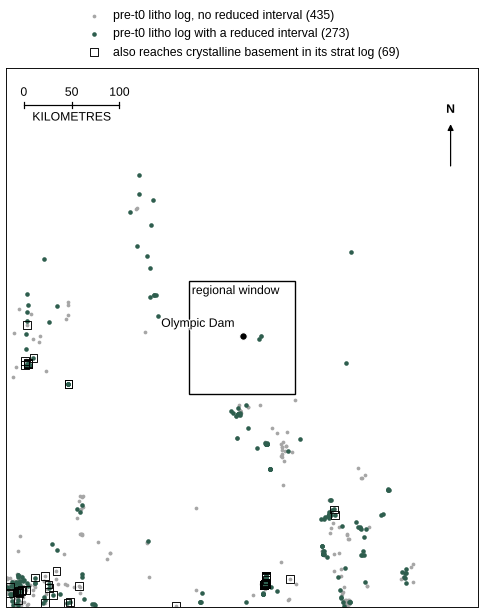

holes with a pre-t0 litho log: 708; with a reduced interval: 273; reaching crystalline basement: 69; inside the regional window: 4 (2 with a reduced interval)
distance to the deposit, holes with a pre-t0 litho log: median 255 km, nearest 17 km


In [3]:
w = win.loc["regional"]
buf = (w.lon_min - 2, w.lon_max + 2, w.lat_min - 2, w.lat_max + 2)
hole = lit_pre.groupby("DRILLHOLE_NO").agg(lon=("lon_dd", "first"), lat=("lat_dd", "first"),
                                          red=("facies_class", lambda s: (s == "reduced").any()))
cont_used = set(con.loc[con.reading == "pandurra_as_cover", "DRILLHOLE_NO"]) & set(hole.index)
asp = 1 / np.cos(np.radians(OD_LAT))
fig, ax = plt.subplots(figsize=(COL15, COL15 * (buf[3] - buf[2]) / ((buf[1] - buf[0]) / asp) * 0.93))
fig.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.02)
nr = hole[~hole.red]; rr = hole[hole.red]
ax.scatter(nr.lon, nr.lat, s=6, color="0.65", lw=0, label=f"pre-t0 litho log, no reduced interval ({len(nr)})")
ax.scatter(rr.lon, rr.lat, s=9, color=FAC_COL["reduced"], lw=0, label=f"pre-t0 litho log with a reduced interval ({len(rr)})")
cu = hole.loc[sorted(cont_used)]
ax.scatter(cu.lon, cu.lat, s=26, facecolor="none", edgecolor="black", lw=0.6, marker="s",
           label=f"also reaches crystalline basement in its strat log ({len(cu)})")
ax.add_patch(plt.Rectangle((w.lon_min, w.lat_min), w.lon_max - w.lon_min, w.lat_max - w.lat_min, fill=False, ec="black", lw=0.9))
ax.text(w.lon_min + 0.03, w.lat_max - 0.04, "regional window", va="top", path_effects=HALO)
ax.plot(OD_LON, OD_LAT, "o", color="black", ms=5, mec="white", mew=0.8, zorder=5)
ax.text(OD_LON - 0.08, OD_LAT + 0.06, "Olympic Dam", va="bottom", ha="right", path_effects=HALO)
ax.set_xlim(buf[0], buf[1]); ax.set_ylim(buf[2], buf[3]); ax.set_aspect(asp)
ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(which="both", length=0)
km_deg = 111.32 * np.cos(np.radians(OD_LAT))
x0, y0 = buf[0] + 0.2, buf[3] - 0.35
for k in (0, 50, 100):
    ax.plot([x0 + k / km_deg] * 2, [y0 - 0.03, y0 + 0.03], color="black", lw=0.8)
    ax.text(x0 + k / km_deg, y0 + 0.06, str(k), ha="center", va="bottom", path_effects=HALO)
ax.plot([x0, x0 + 100 / km_deg], [y0, y0], color="black", lw=0.8)
ax.text(x0 + 50 / km_deg, y0 - 0.06, "KILOMETRES", ha="center", va="top", path_effects=HALO)
nx, ny = buf[1] - 0.3, buf[3] - 0.95
ax.annotate("", xy=(nx, ny + 0.45), xytext=(nx, ny), arrowprops=dict(arrowstyle="-|>", color="black", lw=0.8))
ax.text(nx, ny + 0.5, "N", ha="center", va="bottom", fontweight="bold", path_effects=HALO)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=1)
fig.savefig(FIG / "wp4_L3_00_pre_t0_logged_holes.png", dpi=300)
plt.show()
inwin = hole[(hole.lon >= w.lon_min) & (hole.lon <= w.lon_max) & (hole.lat >= w.lat_min) & (hole.lat <= w.lat_max)]
print(f"holes with a pre-t0 litho log: {len(hole)}; with a reduced interval: {len(rr)}; reaching crystalline "
      f"basement: {len(cu)}; inside the regional window: {len(inwin)} ({int(inwin.red.sum())} with a reduced interval)")
d = lit_pre.groupby("DRILLHOLE_NO").dist_od_km.first()
print(f"distance to the deposit, holes with a pre-t0 litho log: median {d.median():.0f} km, nearest {d.min():.0f} km")


### How to read this figure

Each dot is one hole of the 2-degree buffer that was drilled before t0 and whose lithology log in the database is dated before t0: 708 holes. Grey dots have no interval described in reduced terms (435), dark green dots have at least one (273), and a black square marks the 69 of them whose stratigraphic log also reaches crystalline basement. The black box is the regional window around the deposit. What the reader should see is that the t0 logs lie almost entirely outside the window: only 4 holes are inside it (2 with a reduced interval, all shallow holes, none logged deeper than 80 m), the median hole is 255 km from the deposit and the nearest 17 km. The contact holes cluster on the Gawler Craton margins to the southwest and around the southern Stuart Shelf, so the level's first piece describes the region, not the target.


## Part A, basis piece 1: the facies descriptions in the t0 bore logs

### Step A1. Which logs were written before t0

A hole drilled before t0 is not automatically a t0 log: the description in the database may have been written, or rewritten, years later. Each hole is placed at the year it was drilled against the date of the earliest log the database holds for it, once for the stratigraphic table and once for the lithology table.


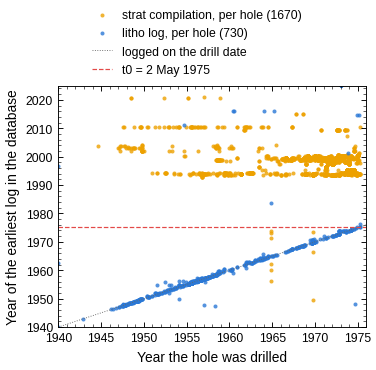

strat: 1670 holes; earliest log before t0: 11 (1%); log dated before the drill date: 5; median logging year 1999
litho: 730 holes; earliest log before t0: 708 (97%); log dated before the drill date: 39; median logging year 1957


In [4]:
def per_hole(df):
    g = df.groupby("DRILLHOLE_NO").agg(drill=("drill_date", "first"), logged=("logging_date", "min"))
    return g.dropna().assign(dx=lambda t: t.drill.map(dec), ly=lambda t: t.logged.map(dec))
hs, hl = per_hole(strat), per_hole(lit)
fig, ax = plt.subplots(figsize=(COL1, COL1 * 0.95))
fig.subplots_adjust(left=0.17, right=0.97, top=0.80, bottom=0.14)
ax.scatter(hs.dx, hs.ly, s=7, color=PIECE_COL[2], lw=0, alpha=0.8, label=f"strat compilation, per hole ({len(hs)})")
ax.scatter(hl.dx, hl.ly, s=7, color=PIECE_COL[1], lw=0, alpha=0.8, label=f"litho log, per hole ({len(hl)})")
ax.plot([1940, 2025], [1940, 2025], color="0.4", lw=0.6, ls=":", label="logged on the drill date")
ax.axhline(T0Y, color="#e34948", lw=0.8, ls="--", label="t0 = 2 May 1975")
ax.set_xlim(1940, 1976); ax.set_ylim(1940, 2025)
ax.set_xlabel("Year the hole was drilled"); ax.set_ylabel("Year of the earliest log in the database")
ax.legend(loc="lower center", bbox_to_anchor=(0.45, 1.0), ncol=1)
fig.savefig(FIG / "wp4_L3_A1_logging_vs_drill_date.png", dpi=300)
plt.show()
for nm, h in (("strat", hs), ("litho", hl)):
    pre = (h.logged < T0).sum(); early = (h.logged < h.drill - pd.Timedelta(days=1)).sum()
    print(f"{nm}: {len(h)} holes; earliest log before t0: {pre} ({pre/len(h):.0%}); "
          f"log dated before the drill date: {early}; median logging year {h.ly.median():.0f}")


### How to read this figure

Each dot is one hole: its drill year along the bottom, the date of the earliest log the database holds for it up the side. Orange dots are the stratigraphic table, blue dots the lithology table; the dotted diagonal is "logged the day it was drilled" and the red dashed line is t0. The lithology logs sit on the diagonal: 708 of 730 holes (97%) have a log written before t0, median logging year 1957. The stratigraphic entries sit in horizontal bands at 1994, 1999 and 2010: only 11 of 1,670 holes (1%) have one written before t0, and the median is 1999. These are Mines and Energy SA interpretations made long after the drilling, so from here on the lithology log is the t0 description and the stratigraphic table is used only to say where basement starts. 39 lithology and 5 stratigraphic holes carry a logging date before their drill date, a data-entry fault to keep in mind.


### Step A2. Redox class against height above the basement top

The annex asks for facies at and near the contact. For every hole whose stratigraphic log reaches basement, each pre-t0 lithology interval is placed by the height of its midpoint above the top of basement, and the redox classes are counted in height bins. Panel (a) treats the Pandurra Formation as cover (basement is crystalline rock only); panel (b) treats it as basement. That ruling is open from Level 1.


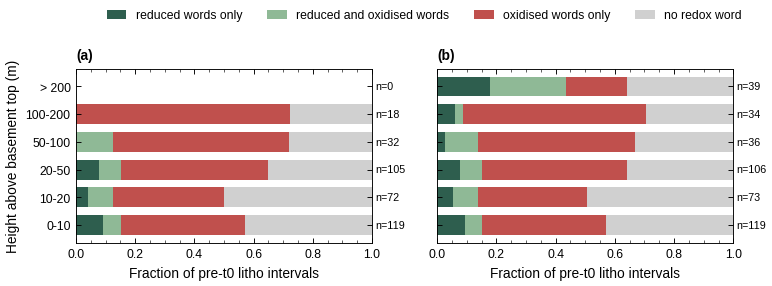

pandurra_as_cover holes 53
facies_class  reduced  mixed  oxidised  none
bin                                         
0-10               11      7        50    51
10-20               3      6        27    36
20-50               8      8        52    37
50-100              0      4        19     9
100-200             0      0        13     5
> 200               0      0         0     0
pandurra_as_basement holes 54
facies_class  reduced  mixed  oxidised  none
bin                                         
0-10               11      7        50    51
10-20               4      6        27    36
20-50               8      8        52    38
50-100              1      4        19    12
100-200             2      1        21    10
> 200               7     10         8    14


In [5]:
BINS = [0, 10, 20, 50, 100, 200, 2000]
BLAB = ["0-10", "10-20", "20-50", "50-100", "100-200", "> 200"]
ORDER = ["reduced", "mixed", "oxidised", "none"]
def heights(reading):
    top = con[con.reading == reading].set_index("DRILLHOLE_NO").basement_top_m
    x = lit_pre[lit_pre.DRILLHOLE_NO.isin(top.index)].copy()
    x["h"] = x.DRILLHOLE_NO.map(top) - 0.5 * (x.DEPTH_FROM_M + x.DEPTH_TO_M)
    x = x[x.h >= 0]
    x["bin"] = pd.cut(x.h, BINS, labels=BLAB, right=False)
    return x
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.6), sharey=True)  # n per bin printed at the right of each panel
fig.subplots_adjust(left=0.10, right=0.93, top=0.78, bottom=0.17, wspace=0.22)
res = {}
for ax, rd, ttl in zip(axes, ["pandurra_as_cover", "pandurra_as_basement"], ["(a)", "(b)"]):
    x = heights(rd)
    tab = pd.crosstab(x.bin, x.facies_class).reindex(index=BLAB, columns=ORDER, fill_value=0)
    fr = tab.div(tab.sum(axis=1), axis=0)
    left = np.zeros(len(fr))
    for c in ORDER:
        ax.barh(range(len(fr)), fr[c], left=left, color=FAC_COL[c], height=0.72, label=FAC_LAB[c])
        left += fr[c].values
    for i, n in enumerate(tab.sum(axis=1)):
        ax.text(1.01, i, f"n={n}", va="center", fontsize=FS_ANNOT, transform=ax.get_yaxis_transform())
    ax.set_xlim(0, 1); ax.set_yticks(range(len(fr))); ax.set_yticklabels(BLAB); ax.invert_yaxis()
    ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel("Fraction of pre-t0 litho intervals")
    res[rd] = (x.DRILLHOLE_NO.nunique(), tab)
axes[0].set_ylabel("Height above basement top (m)")
panel_labels(axes)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.54, 1.02), ncol=4)
fig.savefig(FIG / "wp4_L3_A2_redox_vs_height.png", dpi=300)
plt.show()
for rd, (n, tab) in res.items():
    print(rd, f"holes {n}"); print(tab.to_string())


### How to read this figure

Each bar is one height band above the top of basement (0 at the contact, rising upward), and its colours are the share of the pre-t0 lithology intervals in that band that were described in reduced words only (dark green), in both reduced and oxidised words (light green), in oxidised words only (red), or in neither (grey); n is the number of intervals. Panel (a) takes basement as crystalline rock only, panel (b) counts the Pandurra Formation as basement. The two panels agree in the lowest 50 m, where the same holes dominate: in the 0 to 10 m band 11 of 119 intervals (9%) read reduced and 50 (42%) oxidised. Oxidised descriptions outnumber reduced ones in every band. Only panel (b) has intervals more than 200 m above its basement, and there reduced and mixed words reach 17 of 39, because those holes pass through thick Adelaidean shale above the Pandurra.


### Step A3. Marginal presence of reduced facies at the contact

The annex's marginal probability is estimated directly: the fraction of contact holes with at least one reduced interval whose base lies within W metres above the basement top, for W from 5 to 100 m, with a 90% interval from a Beta posterior under a flat prior (Beta(1 + k, 1 + n - k) for k reduced holes out of n). The same is shown counting mixed intervals as reduced, and, for comparison only, the class of the lowest cover unit in the later stratigraphic compilation.


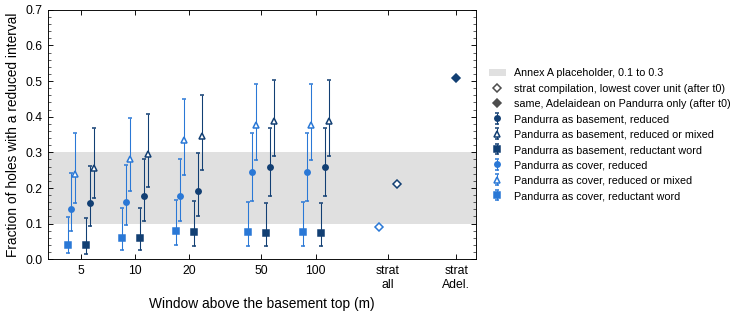

             reading  W_m            class  n  k    p  lo90  hi90
   pandurra_as_cover    5   reductant word 50  2 0.04  0.02  0.12
   pandurra_as_cover    5          reduced 50  7 0.14  0.08  0.24
   pandurra_as_cover    5 reduced or mixed 50 12 0.24  0.16  0.35
   pandurra_as_cover   10   reductant word 50  3 0.06  0.03  0.15
   pandurra_as_cover   10          reduced 50  8 0.16  0.10  0.27
   pandurra_as_cover   10 reduced or mixed 50 14 0.28  0.19  0.40
   pandurra_as_cover   20   reductant word 51  4 0.08  0.04  0.17
   pandurra_as_cover   20          reduced 51  9 0.18  0.11  0.28
   pandurra_as_cover   20 reduced or mixed 51 17 0.33  0.24  0.45
   pandurra_as_cover   50   reductant word 53  4 0.08  0.04  0.16
   pandurra_as_cover   50          reduced 53 13 0.25  0.16  0.36
   pandurra_as_cover   50 reduced or mixed 53 20 0.38  0.28  0.49
   pandurra_as_cover  100   reductant word 53  4 0.08  0.04  0.16
   pandurra_as_cover  100          reduced 53 13 0.25  0.16  0.36
   pandurr

In [6]:
WS = [5, 10, 20, 50, 100]
HITS = {}
def p_contact(reading, W, classes=("reduced",)):
    top = con[con.reading == reading].set_index("DRILLHOLE_NO").basement_top_m
    x = lit_pre[lit_pre.DRILLHOLE_NO.isin(top.index)].copy()
    x["h"] = x.DRILLHOLE_NO.map(top) - x.DEPTH_TO_M          # height of the interval's base above the basement top
    x = x[(x.h >= -0.5) & (x.h <= W)]
    if classes == "reductant":   # strict: a reductant word (carbonaceous, pyrite, sulphides), colour ignored
        hit = x.groupby("DRILLHOLE_NO").reductant_words.agg(lambda s: (s.fillna("") != "").any())
    else:
        hit = x.groupby("DRILLHOLE_NO").facies_class.agg(lambda s: s.isin(classes).any())
    n, k = len(hit), int(hit.sum())
    lo, hi = stats.beta(1 + k, 1 + n - k).ppf([0.05, 0.95])
    HITS[(reading, W, str(classes))] = list(hit[hit].index)
    return n, k, k / n, lo, hi
rows = []
for rd in ["pandurra_as_cover", "pandurra_as_basement"]:
    for W in WS:
        for cl, nm in [("reductant", "reductant word"), (("reduced",), "reduced"), (("reduced", "mixed"), "reduced or mixed")]:
            rows.append((rd, W, nm) + p_contact(rd, W, cl))
P = pd.DataFrame(rows, columns=["reading", "W_m", "class", "n", "k", "p", "lo90", "hi90"])
sc = con[con.contact_facies_class != "no cover interval logged"]
S = sc.groupby("reading").contact_facies_class.agg(n="size", k=lambda s: (s == "reduced").sum())
S["p"] = S.k / S.n
# which cover sits directly on basement, and does that hole have a pre-t0 litho log?
age = strat.drop_duplicates(["DRILLHOLE_NO", "STRAT_UNIT_NAME"]).set_index(["DRILLHOLE_NO", "STRAT_UNIT_NAME"]).age_class
cc = con.copy()
cc["cover_age"] = [age.get((h, u), "no cover logged") for h, u in zip(cc.DRILLHOLE_NO, cc.contact_cover_unit)]
cc["pre_t0_litho"] = cc.DRILLHOLE_NO.isin(set(lit_pre.DRILLHOLE_NO))
ad = cc[(cc.reading == "pandurra_as_basement") & (cc.cover_age == "Adelaidean")]
pad = (ad.contact_facies_class == "reduced").mean()

fig, ax = plt.subplots(figsize=(COL2, 2.8))
fig.subplots_adjust(left=0.08, right=0.62, top=0.97, bottom=0.16)
ax.axhspan(0.1, 0.3, color="0.88", lw=0, label="Annex A placeholder, 0.1 to 0.3")
off = {"pandurra_as_cover": -0.05, "pandurra_as_basement": 0.05}
mk = {"reductant word": "s", "reduced": "o", "reduced or mixed": "^"}
dx = {"reductant word": -0.022, "reduced": 0.0, "reduced or mixed": 0.022}
col = {"pandurra_as_cover": PIECE_COL[1], "pandurra_as_basement": "#123f73"}
lab_rd = {"pandurra_as_cover": "Pandurra as cover", "pandurra_as_basement": "Pandurra as basement"}
for (rd, cl), g in P.groupby(["reading", "class"]):
    xs = np.log10(g.W_m) + off[rd] + dx[cl]
    ax.errorbar(xs, g.p, yerr=[g.p - g.lo90, g.hi90 - g.p], fmt=mk[cl], ms=3.5, color=col[rd],
                mfc="white" if cl == "reduced or mixed" else col[rd], lw=0.7, capsize=1.2, label=f"{lab_rd[rd]}, {cl}")
for rd, r in S.iterrows():
    ax.plot(np.log10(250) + off[rd], r.p, "D", ms=4, color=col[rd], mfc="white")
ax.plot(np.log10(600), pad, "D", ms=4, color=col["pandurra_as_basement"])
ax.plot([], [], "D", ms=4, color="0.3", mfc="white", label="strat compilation, lowest cover unit (after t0)")
ax.plot([], [], "D", ms=4, color="0.3", label="same, Adelaidean on Pandurra only (after t0)")
ax.set_xticks(np.log10(WS + [250, 600])); ax.set_xticklabels([str(w) for w in WS] + ["strat\nall", "strat\nAdel."])
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_xlabel("Window above the basement top (m)"); ax.set_ylabel("Fraction of holes with a reduced interval")
ax.set_ylim(0, 0.7)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=FS_ANNOT)
fig.savefig(FIG / "wp4_L3_A3_marginal_presence.png", dpi=300)
plt.show()
print(P.round(2).to_string(index=False))
print(S.round(3).to_string())
cu = con[con.reading == "pandurra_as_cover"].set_index("DRILLHOLE_NO").contact_cover_unit
for key, nm in [(("pandurra_as_cover", 20, "reductant"), "reductant word"), (("pandurra_as_cover", 20, "('reduced',)"), "reduced")]:
    print(f"lowest strat cover unit of the holes hit within 20 m ({nm}):", cu.reindex(HITS[key]).fillna("none logged").value_counts().to_dict())
print(pd.crosstab([cc.reading, cc.cover_age], cc.pre_t0_litho).to_string())
ad = cc[(cc.reading == "pandurra_as_basement") & (cc.cover_age == "Adelaidean")]
print("Adelaidean on Pandurra, strat compilation:", len(ad), "holes;", int((ad.contact_facies_class == "reduced").sum()),
      f"reduced ({pad:.2f});", ad.contact_cover_unit.value_counts().head(4).to_dict())


### How to read this figure

Each mark is the fraction of contact holes (about 50 to 54) that have at least one interval of a given kind whose base lies within the window above the basement top, with its 90% interval. Light blue treats Pandurra as cover, dark blue as basement. Squares count only reductant words (carbonaceous, pyrite, marcasite, sulphides), dots count reduced colours as well, open triangles also count mixed descriptions. The grey band is the annex's 0.1 to 0.3. Within 20 m, the strict count gives 0.08 (4 of 51 holes, 90% 0.04 to 0.17), the colour count 0.18 (9 of 51, 0.11 to 0.28), and including mixed 0.33 (17 of 51). The pre-t0 logs therefore bracket the annex band rather than confirm it, and which end applies depends on what a word like "grey" is taken to mean. Almost all the logged holes reach basement under young cover: every strict hit and 8 of the 9 colour hits sit under post-Cambrian cover (Tertiary, Quaternary, Cretaceous weathering or Permian units; the ninth has no cover sample), and only 1 (Pandurra as cover) or 2 (Pandurra as basement) pre-t0 lithology logs cross an Adelaidean-on-basement contact. The diamonds, from the later stratigraphic compilation, show what that contact looks like when it is sampled: the lowest cover unit is reduced in 16 of 179 holes (0.09) with crystalline basement and 64 of 304 (0.21) with Pandurra as basement, and where Adelaidean rock sits on Pandurra it is reduced in 53 of 104 holes (0.51), mostly Tapley Hill Formation.


### Step A4. The written pre-t0 statements

The database gives a count; the written reports give the geology an explorer would have read. Each pre-t0 document in the level folder is placed at its date: the Mount Gunson sub-reports cut from their envelopes and Johns's Bulletin 41. The Mount Gunson items that are dated after t0 or could not be dated from their pages are counted but left out of the folder.


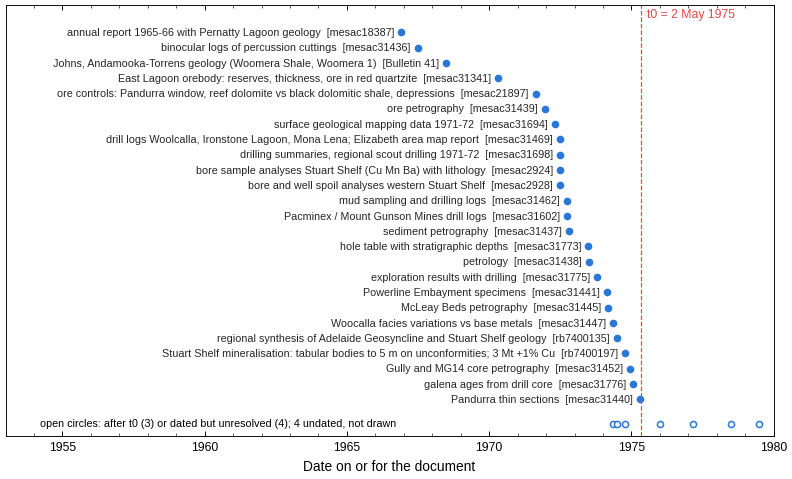

pre-t0 documents drawn: 25 (Mount Gunson 24, plus Bulletin 41)
Bulletin 41: e Mount Gunson locality is related to an erosional "high" composed of Pernatty Grit. Where unweathered the shales are purple, red or brown in colour with green shale partings. The predominantly red or purple colour probably reflects deposition under oxidising conditions with the production of green bands due to fluctuating reducing conditions and the formation of ferrous compounds. The shales weather readily and are seldom seen in outcrop. T


In [7]:
tl = mg.copy()
tl["d"] = pd.to_datetime(tl.date_plot, errors="coerce")
tl = pd.concat([tl, pd.DataFrame([{"record": "Bulletin 41", "status_t0": "before", "d": pd.Timestamp("1968-07-01"),
                                   "facies_content": "Johns, Andamooka-Torrens geology (Woomera Shale, Woomera 1)"}])])
tl["y"] = tl.d.map(lambda t: dec(t) if pd.notna(t) else np.nan)
SHORT = {"mesac18387": "annual report 1965-66 with Pernatty Lagoon geology"}
tl["facies_content"] = [SHORT.get(r, f) for r, f in zip(tl.record, tl.facies_content)]
bef = tl[tl.status_t0 == "before"].sort_values("d").reset_index(drop=True)
oth = tl[(tl.status_t0 != "before") & tl.d.notna()]
und = tl[(tl.status_t0 != "before") & tl.d.isna()]
fig, ax = plt.subplots(figsize=(COL2, 0.16 * len(bef) + 0.9))
fig.subplots_adjust(left=0.02, right=0.99, top=0.90, bottom=0.10)
for i, r in bef.iterrows():
    ax.plot(r.y, i, "o", color=PIECE_COL[1], ms=4)
    ax.text(r.y - 0.25, i, f"{r.facies_content}  [{r.record}]", va="center", ha="right", fontsize=FS_ANNOT, color="0.15")
yo = len(bef) + 0.6
ax.plot(oth.y, np.full(len(oth), yo), "o", color=PIECE_COL[1], mfc="white", ms=4)
ax.text(1954.2, yo, f"open circles: after t0 ({(oth.status_t0 == 'after').sum()}) or dated but unresolved "
        f"({(oth.status_t0 == 'unresolved').sum()}); {len(und)} undated, not drawn", va="center", ha="left", fontsize=FS_ANNOT)
ax.axvline(T0Y, color="#e34948", lw=0.8, ls="--")
ax.text(T0Y + 0.2, -1.2, "t0 = 2 May 1975", color="#e34948", va="center")
ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(yo + 0.8, -1.8)
ax.set_xlim(1953, 1980); ax.set_xlabel("Date on or for the document")
fig.savefig(FIG / "wp4_L3_A4_pre_t0_documents.png", dpi=300)
plt.show()
print(f"pre-t0 documents drawn: {len(bef)} (Mount Gunson {len(bef) - 1}, plus Bulletin 41)")
i = b41.find("reducing conditions")
print("Bulletin 41:", " ".join(b41[i - 330:i + 120].split()))


### How to read this figure

Each row is one document in the level folder, placed at the date read on or for it (year-only items mid-year), with its SARIG record in brackets; the red dashed line is t0. The 23 filled circles are the 22 Mount Gunson sub-reports and envelopes dated before t0 plus Johns's Bulletin 41 (1968). The bottom row holds the Mount Gunson items that were left out: 3 dated after t0 and 3 dated but not placed before t0 with confidence (open circles), and 4 that carry no readable date. What the reader should see is that the written record is dense in 1972 to early 1975 and all from one district, Mount Gunson, roughly 100 km south of the deposit. It holds drill logs, petrography and a May 1974 study of facies variations in the Woocalla Formation and their relation to base metals. Bulletin 41 gives the period reading of the red and green shales: "deposition under oxidising conditions with the production of green bands due to fluctuating reducing conditions".


### Verdict on piece 1

On disk and in state. The t0 bore logs are the lithology logs (708 holes with a log written before t0), not the stratigraphic table, which is a 1990 onward compilation. Read with a word screen, the logs give a marginal presence of reduced facies within 20 m of basement of 0.08 (strict, reductant words) to 0.18 (colour words). That brackets the annex's 0.1 to 0.3, but it describes young cover on the craton margins, not the Adelaidean-on-basement contact the concept needs. Only one or two pre-t0 lithology logs cross that contact. The number for that contact comes from the later compilation, 53 of 104 holes reduced where Adelaidean rock sits on Pandurra, and from the written Mount Gunson record (Woocalla facies, 1974; ore genesis, October 1974). Both say the reduced unit on the Stuart Shelf is Tapley Hill and Whyalla-Woocalla shale and sandstone above the Pandurra. For the prior, the marginal presence is better written as two factors: the chance that the Adelaidean shelf sequence reaches the target position (a Level 1 question), times the chance that its basal unit is reduced where present (about one half from the compilation, to be carried as a translation, not a t0 number). The word screen is crude: "grey" is not a proof of reducing conditions, which is why the strict count is shown.


## Part B, basis piece 2: the pre-1975 analog literature

### Step B1. Belt and patch lengths as the analog papers state them

The annex's correlation structure is two lengths: belts of tens of kilometres containing patches of 1 to 10 km. Every length statement found in the Liege 1974 papers is drawn on one log axis, with the row number of the transcription table, against the two annex ranges.


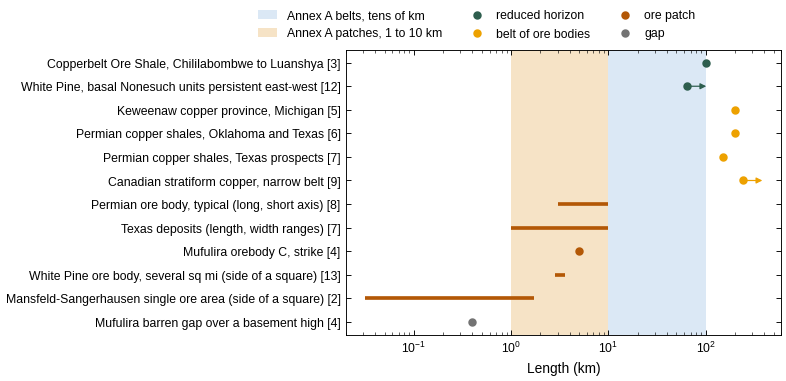

                                                   label               kind     lo     hi  row  lower_bound
         Copperbelt Ore Shale, Chililabombwe to Luanshya    reduced horizon 100.00 100.00    3        False
   White Pine, basal Nonesuch units persistent east-west    reduced horizon  64.00  64.00   12         True
                      Keweenaw copper province, Michigan belt of ore bodies 200.00 200.00    5        False
               Permian copper shales, Oklahoma and Texas belt of ore bodies 200.00 200.00    6        False
                  Permian copper shales, Texas prospects belt of ore bodies 150.00 150.00    7        False
                 Canadian stratiform copper, narrow belt belt of ore bodies 241.35 241.35    9         True
            Permian ore body, typical (long, short axis)          ore patch   3.00  10.00    8        False
                   Texas deposits (length, width ranges)          ore patch   1.00  10.00    7        False
                            

In [8]:
# lengths read from level3_analog_dimensions_pre_t0.csv (row numbers in brackets); km unless stated
L = [  # label, kind, lo, hi, dims row, lower bound only
    ("Copperbelt Ore Shale, Chililabombwe to Luanshya", "reduced horizon", 100, 100, 3, False),
    ("White Pine, basal Nonesuch units persistent east-west", "reduced horizon", 64, 64, 12, True),
    ("Keweenaw copper province, Michigan", "belt of ore bodies", 200, 200, 5, False),
    ("Permian copper shales, Oklahoma and Texas", "belt of ore bodies", 200, 200, 6, False),
    ("Permian copper shales, Texas prospects", "belt of ore bodies", 150, 150, 7, False),
    ("Canadian stratiform copper, narrow belt", "belt of ore bodies", 150 * 1.609, 150 * 1.609, 9, True),
    ("Permian ore body, typical (long, short axis)", "ore patch", 3, 10, 8, False),
    ("Texas deposits (length, width ranges)", "ore patch", 1, 10, 7, False),
    ("Mufulira orebody C, strike", "ore patch", 5, 5, 4, False),
    ("White Pine ore body, several sq mi (side of a square)", "ore patch", 2.8, 3.6, 13, False),
    ("Mansfeld-Sangerhausen single ore area (side of a square)", "ore patch", np.sqrt(1e-3), np.sqrt(3), 2, False),
    ("Mufulira barren gap over a basement high", "gap", 0.4, 0.4, 4, False),
]
L = pd.DataFrame(L, columns=["label", "kind", "lo", "hi", "row", "lower_bound"])
KC = {"reduced horizon": FAC_COL["reduced"], "belt of ore bodies": PIECE_COL[2], "ore patch": "#b35806", "gap": "0.45"}
fig, ax = plt.subplots(figsize=(COL2, 3.6))
fig.subplots_adjust(left=0.43, right=0.98, top=0.86, bottom=0.14)
ax.axvspan(10, 100, color="#dbe8f5", lw=0, label="Annex A belts, tens of km")
ax.axvspan(1, 10, color="#f6e3c6", lw=0, label="Annex A patches, 1 to 10 km")
for i, r in L.iterrows():
    if r.lo == r.hi:
        ax.plot(r.lo, i, "o", color=KC[r.kind], ms=4.5)
    else:
        ax.plot([r.lo, r.hi], [i, i], color=KC[r.kind], lw=2.4, solid_capstyle="butt")
    if r.lower_bound:
        ax.annotate("", xy=(r.lo * 1.7, i), xytext=(r.lo, i), arrowprops=dict(arrowstyle="-|>", color=KC[r.kind], lw=0.8))
ax.set_yticks(range(len(L))); ax.set_yticklabels([f"{a} [{b}]" for a, b in zip(L.label, L.row)])
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlim(0.02, 600); ax.set_xlabel("Length (km)")
for k, c in KC.items():
    ax.plot([], [], "o", color=c, ms=4.5, label=k)
ax.legend(loc="lower center", bbox_to_anchor=(0.3, 1.0), ncol=3)
fig.savefig(FIG / "wp4_L3_B1_analog_lengths.png", dpi=300)
plt.show()
print(L.assign(lo=L.lo.round(2), hi=L.hi.round(2)).to_string(index=False))
ok = man[man.status == "ok"]
print("papers on disk:", "; ".join(f"{a} ({str(d)[:4]})" for a, d in zip(ok.citation_authors, ok.citation_date)))


### How to read this figure

Each row is one length stated in a 1974 Liege paper, with its row number in the transcription table; dots are single values, bars ranges, and the arrow marks a lower bound. The blue band is the annex's "tens of km" for belts, the tan band its 1 to 10 km for patches, on a logarithmic axis. Dark green is a reduced host horizon, orange a belt of ore bodies, brown an ore patch, grey a barren gap. What the reader should see is that the belts stated in the analog papers sit at or above the top of "tens of km": the basal Nonesuch units at White Pine persist for at least 64 km east-west (a lower bound, exposure ends), the Copperbelt Ore Shale is traced for about 100 km, and the mineralised belts run 150 to 240 km. The ore patches fall in the annex's 1 to 10 km (Permian bodies about 10 by 3 km, Texas deposits 3 to 10 km long and 1 to 4 km wide, the White Pine ore body about 3 km on a side for "several square miles", Mufulira C 5 km along strike), and the Kupferschiefer ore areas of Mansfeld are smaller, about 0.03 to 1.7 km on a side. The only barren gap stated is 400 m, over a basement high at Mufulira.


### Step B2. What fraction is occupied, and by what

A patch length only makes sense with the fraction it occupies. The analog papers give fractions of two different things: the share of a belt occupied by ore, and the share of a basin where the reduced host is present. Both are set against the annex's marginal presence and the Step A3 estimate.


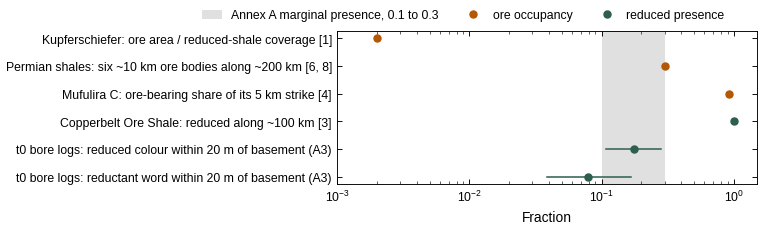

                                                     label             kind     f    lo    hi
     Kupferschiefer: ore area / reduced-shale coverage [1]    ore occupancy 0.002   NaN   NaN
Permian shales: six ~10 km ore bodies along ~200 km [6, 8]    ore occupancy 0.300   NaN   NaN
      Mufulira C: ore-bearing share of its 5 km strike [4]    ore occupancy 0.920   NaN   NaN
           Copperbelt Ore Shale: reduced along ~100 km [3] reduced presence 1.000   NaN   NaN
 t0 bore logs: reduced colour within 20 m of basement (A3) reduced presence 0.176 0.108 0.283
 t0 bore logs: reductant word within 20 m of basement (A3) reduced presence 0.078 0.039 0.167


In [9]:
p20 = P[(P.reading == "pandurra_as_cover") & (P.W_m == 20) & (P["class"] == "reduced")].iloc[0]
s20 = P[(P.reading == "pandurra_as_cover") & (P.W_m == 20) & (P["class"] == "reductant word")].iloc[0]
F = pd.DataFrame([
    ("Kupferschiefer: ore area / reduced-shale coverage [1]", "ore occupancy", 0.002, None, None),
    ("Permian shales: six ~10 km ore bodies along ~200 km [6, 8]", "ore occupancy", 6 * 10 / 200, None, None),
    ("Mufulira C: ore-bearing share of its 5 km strike [4]", "ore occupancy", 1 - 0.4 / 5, None, None),
    ("Copperbelt Ore Shale: reduced along ~100 km [3]", "reduced presence", 1.0, None, None),
    ("t0 bore logs: reduced colour within 20 m of basement (A3)", "reduced presence", p20.p, p20.lo90, p20.hi90),
    ("t0 bore logs: reductant word within 20 m of basement (A3)", "reduced presence", s20.p, s20.lo90, s20.hi90),
], columns=["label", "kind", "f", "lo", "hi"])
FK = {"ore occupancy": "#b35806", "reduced presence": FAC_COL["reduced"]}
fig, ax = plt.subplots(figsize=(COL2, 2.2))
fig.subplots_adjust(left=0.45, right=0.98, top=0.83, bottom=0.2)
ax.axvspan(0.1, 0.3, color="0.88", lw=0, label="Annex A marginal presence, 0.1 to 0.3")
for i, r in F.iterrows():
    ax.plot(r.f, i, "o", color=FK[r.kind], ms=4.5)
    if pd.notna(r.lo):
        ax.plot([r.lo, r.hi], [i, i], color=FK[r.kind], lw=1.0)
ax.set_yticks(range(len(F))); ax.set_yticklabels(F.label); ax.invert_yaxis()
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_xscale("log"); ax.set_xlim(1e-3, 1.5); ax.set_xlabel("Fraction")
for k, c in FK.items():
    ax.plot([], [], "o", color=c, ms=4.5, label=k)
ax.legend(loc="lower center", bbox_to_anchor=(0.3, 1.0), ncol=3)
fig.savefig(FIG / "wp4_L3_B2_fractions.png", dpi=300)
plt.show()
print(F.round(3).to_string(index=False))


### How to read this figure

Each row is a fraction on a logarithmic axis: brown rows are the share of a belt occupied by ore, green rows the share of the ground where the reduced host is present, and the grey band is the annex's 0.1 to 0.3 marginal presence. The Kupferschiefer ore covers about 0.002 of the reduced shale's extent, the six Permian ore bodies about 0.30 of their 200 km belt, and Mufulira C carries ore along 0.92 of its 5 km strike. The Copperbelt Ore Shale is reduced along its whole 100 km, a presence of 1. The two t0 bore-log estimates from Step A3 are 0.18 (colour) and 0.08 (strict). What the reader should see is that the analog papers describe reduced hosts as continuous sheets or belts, and patches of 1 to 10 km as ore within them, so the annex's 0.1 to 0.3 with 1 to 10 km patches matches the analogs' ore occupancy better than their reduced-facies presence.


### Verdict on piece 2

Mostly on disk and in state: ten papers of the 1974 Liege volume and the two White Pine papers (White and Wright 1954, Brown 1971), all printed before t0, with fifteen statements transcribed. They support the annex's structure with one correction. The belt scale in the analogs is from at least 64 km (White Pine, a lower bound) to 100 to 240 km, at or above the top of "tens of km". The 1 to 10 km patches are ore bodies inside a continuous reduced host, not patches of reduced facies. In the Kupferschiefer, what forms patches is the oxidised Rote Faule, not the reduced shale. Rowlands (1974), the one local paper, places the Adelaidean reduced hosts in "sinuous palaeolittoral zones" close to unconformities, with basement highs at Gunson. That favours belts elongated along palaeoshorelines and interrupted over highs, the same geometry as the Mufulira gap. White Pine adds the vertical scale: the redox front (Brown's Cu-Fe fringe) is one blanket surface 6 to 15 m above the base of 600 ft of grey Nonesuch siltstone, over thousands of feet of red beds. Not obtainable: Mendelsohn (1961) and Ensign et al. (1968), print only. They stand as named sources with in-state stand-ins: the Liege Copperbelt papers for Mendelsohn, and White and Wright (two of Ensign's co-authors) with Brown for Ensign. Article 800 of the Liege volume is 1989 and is kept out.


## Part C. Mount Gunson, the analog the concept named

WMC's own first statement of the EL 190 concept (the first quarterly, a quarter after t0) named stratiform copper of the Cattle Grid type at Mount Gunson, 115 km south of the deposit, as the model. So both basis pieces meet here: Mount Gunson is the one analog on the Stuart Shelf itself, and its pre-t0 reports are also bore logs of the same reduced unit. This part reads a dossier transcribed from 12 documents dated 1941 to October 1974 (`mount_gunson_analog/mount_gunson_t0_dossier.csv`, one row per statement, with quote and page), plus the 1971 LD holes of RB 72/00189 and the positions of the district's pre-t0 holes. The next cell loads them.


In [10]:
MG = L3 / "mount_gunson_analog"
dos = pd.read_csv(MG / "mount_gunson_t0_dossier.csv")
ld = pd.read_csv(MG / "mount_gunson_LD_holes_1971.csv")
mgh = pd.read_csv(MG / "mount_gunson_t0_holes.csv")
def hk(lon1, lat1, lon2, lat2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))
pos = mgh.set_index("DH_NAME")[["lon_dd", "lat_dd"]]
GUN = tuple(pos.loc["LY 2"])            # CSR stratigraphic hole LY 2 (1974), at the Mount Gunson workings
WOO = tuple(pos.loc["WOOMERA 1"])
d_gun_od = hk(*GUN, OD_LON, OD_LAT); d_gun_woo = hk(*GUN, *WOO); d_woo_od = hk(*WOO, OD_LON, OD_LAT)
print(f"dossier: {len(dos)} statements from {dos.record.nunique()} documents; status {dos.status_t0.value_counts().to_dict()}")
print(f"Mount Gunson (LY 2) to Olympic Dam {d_gun_od:.0f} km; to Woomera 1 {d_gun_woo:.0f} km; Woomera 1 to Olympic Dam {d_woo_od:.0f} km")
print(f"pre-t0 district holes with positions: {mgh.groupby('group').size().to_dict()}")


dossier: 37 statements from 13 documents; status {'before': 36, 'unresolved': 1}
Mount Gunson (LY 2) to Olympic Dam 115 km; to Woomera 1 40 km; Woomera 1 to Olympic Dam 82 km
pre-t0 district holes with positions: {'BEDA BORE': 1, 'LD': 7, 'LY': 2, 'MF': 13, 'MG': 51, 'WOOMERA 1': 1, 'WP': 27}


### Step C1. The district, and how far it is from the target

The map shows the Mount Gunson district as a t0 reader could have assembled it from open file: the workings and their 1973-75 drilling, the 1968 Winnie Pinnie and 1973-74 Lake MacFarlane programmes, the seven 1971 LD holes whose Woocalla intersections RB 72/00189 tabulates, and the two older bores Johns (1972) cites for the black shale, Woomera 1 and Beda Bore. Positions are from the SA Geodata details export; the thicknesses are the 1972 report's.


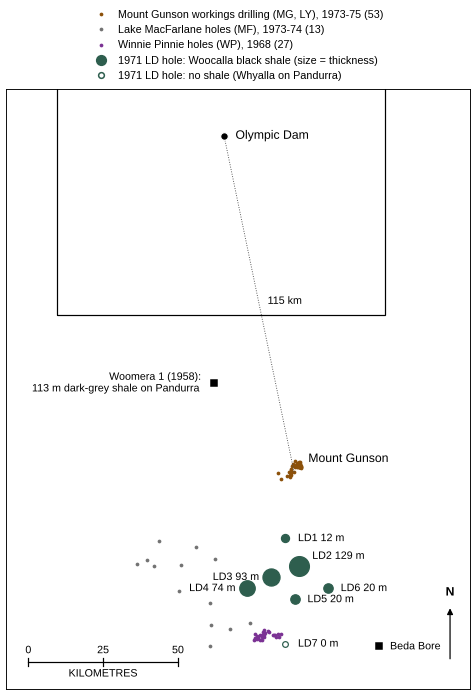

hole  woocalla_from_ft  woocalla_to_ft  woocalla_thickness_m  woocalla_present
 LD1            260.00          298.50                  11.7              True
 LD2            179.50          601.83                 128.7              True
 LD3            324.08          629.00                  92.9              True
 LD4            200.00          443.75                  74.3              True
 LD5            204.50          271.00                  20.3              True
 LD6            150.00          215.67                  20.0              True
 LD7               NaN             NaN                   0.0             False
LD holes to Olympic Dam: 136-171 km


In [11]:
GC = {"LD": FAC_COL["reduced"], "MG": "#8c510a", "LY": "#8c510a", "MF": "0.45", "WP": "#7b3294"}
fig, ax = plt.subplots(figsize=(COL15, COL15 * 1.18))
fig.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.02)
asp = 1 / np.cos(np.radians(-31.2))
for g, lab in [("MG", "Mount Gunson workings drilling (MG, LY), 1973-75"), ("MF", "Lake MacFarlane holes (MF), 1973-74"),
               ("WP", "Winnie Pinnie holes (WP), 1968")]:
    s = mgh[mgh.group.isin([g] + (["LY"] if g == "MG" else []))]
    ax.scatter(s.lon_dd, s.lat_dd, s=6, color=GC[g], lw=0, label=f"{lab} ({len(s)})")
l7 = ld.merge(mgh, left_on="hole", right_on=mgh.DH_NAME.str.replace(" ", ""), how="left")
for r in l7.itertuples():
    pres = r.woocalla_present
    ax.scatter(r.lon_dd, r.lat_dd, s=14 + 1.2 * r.woocalla_thickness_m, marker="o",
               facecolor=FAC_COL["reduced"] if pres else "white", edgecolor=FAC_COL["reduced"], lw=0.8, zorder=4)
    dx, ha = (-0.04, "right") if r.hole in ("LD3", "LD4") else (0.045, "left")
    dy = 0.03 if r.hole == "LD2" else 0.0
    ax.text(r.lon_dd + dx, r.lat_dd + dy, f"{r.hole} {r.woocalla_thickness_m:.0f} m", fontsize=FS_ANNOT, va="center", ha=ha, path_effects=HALO)
ax.scatter([], [], s=40, facecolor=FAC_COL["reduced"], edgecolor=FAC_COL["reduced"], label="1971 LD hole: Woocalla black shale (size = thickness)")
ax.scatter([], [], s=14, facecolor="white", edgecolor=FAC_COL["reduced"], label="1971 LD hole: no shale (Whyalla on Pandurra)")
for nm, xy, dx, ha in [("Woomera 1 (1958):\n113 m dark-grey shale on Pandurra", WOO, -0.04, "right"), ("Beda Bore", tuple(pos.loc["BEDA BORE"]), 0.04, "left")]:
    ax.plot(*xy, "s", color="black", ms=4); ax.text(xy[0] + dx, xy[1], nm, fontsize=FS_ANNOT, ha=ha, va="center", path_effects=HALO)
ax.plot(OD_LON, OD_LAT, "o", color="black", ms=5, mec="white", mew=0.8, zorder=5)
ax.text(OD_LON + 0.04, OD_LAT, "Olympic Dam", va="center", path_effects=HALO)
ax.plot([GUN[0], OD_LON], [GUN[1], OD_LAT], color="0.3", lw=0.6, ls=":")
ax.text((GUN[0] + OD_LON) / 2 + 0.03, (GUN[1] + OD_LAT) / 2, f"{d_gun_od:.0f} km", fontsize=FS_ANNOT, path_effects=HALO)
ax.text(GUN[0] + 0.05, GUN[1] + 0.03, "Mount Gunson", path_effects=HALO)
w = win.loc["regional"]
ax.add_patch(plt.Rectangle((w.lon_min, w.lat_min), w.lon_max - w.lon_min, w.lat_max - w.lat_min, fill=False, ec="black", lw=0.8))
ax.set_xlim(136.12, 137.75); ax.set_ylim(-32.1, -30.3); ax.set_aspect(asp)
ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(which="both", length=0)
km_deg = 111.32 * np.cos(np.radians(-31.2)); x0, y0 = 136.2, -32.02
for k in (0, 25, 50):
    ax.plot([x0 + k / km_deg] * 2, [y0 - 0.012, y0 + 0.012], color="black", lw=0.8)
    ax.text(x0 + k / km_deg, y0 + 0.02, str(k), ha="center", va="bottom", fontsize=FS_ANNOT, path_effects=HALO)
ax.plot([x0, x0 + 50 / km_deg], [y0, y0], color="black", lw=0.8)
ax.text(x0 + 25 / km_deg, y0 - 0.02, "KILOMETRES", ha="center", va="top", fontsize=FS_ANNOT, path_effects=HALO)
ax.annotate("", xy=(137.68, -31.85), xytext=(137.68, -32.02), arrowprops=dict(arrowstyle="-|>", color="black", lw=0.8))
ax.text(137.68, -31.83, "N", ha="center", va="bottom", fontweight="bold", path_effects=HALO)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=1, fontsize=FS_ANNOT)
fig.savefig(FIG / "wp4_L3_C1_mount_gunson_district.png", dpi=300)
plt.show()
print(ld[["hole", "woocalla_from_ft", "woocalla_to_ft", "woocalla_thickness_m", "woocalla_present"]].to_string(index=False))
print(f"LD holes to Olympic Dam: {l7.dist_od_km.min():.0f}-{l7.dist_od_km.max():.0f} km")


### How to read this figure

Brown dots are the 53 holes drilled at the Mount Gunson workings in 1973-75 (MG and LY series), grey dots the 13 Lake MacFarlane holes (1973-74), purple dots the 27 Winnie Pinnie holes (1968). Filled green circles are the 1971 LD holes that cut Woocalla black or dolomitic shale, sized by its thickness (12 to 129 m); the open circle is LD7, where the Whyalla Sandstone sits directly on the Pandurra. Black squares are Woomera 1 (1958) and Beda Bore. The black box is the regional window around Olympic Dam, and the dotted line runs from Mount Gunson (hole LY 2) to the deposit, 115 km. What the reader should see is that everything known about the analog lies 115 to 171 km south of the target (the LD holes are 136 to 171 km away), and that the one deep t0 hole between the two, Woomera 1, 82 km from the deposit and 40 km from Mount Gunson, found 113 m of dark-grey laminated shale resting on the Pandurra. That hole is the only t0 point that carries the reduced unit toward the target.


### Step C2. What a reader at t0 could know about Mount Gunson

Each statement in the dossier is tagged with a topic. The matrix shows which document said what, so the reader can see where the Level 3 and Level 4 numbers come from and how late most of them arrived.


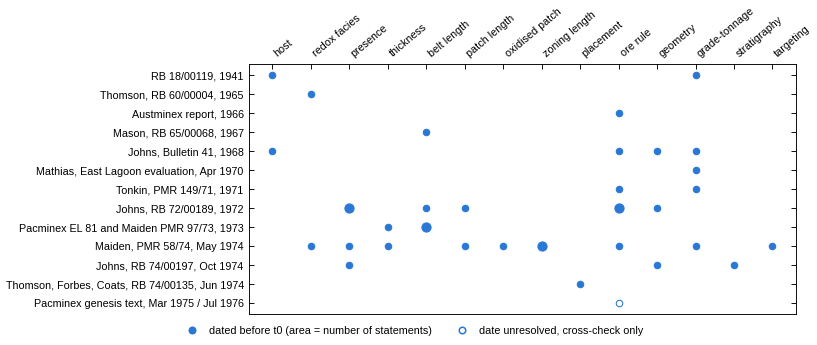

record
2019d016314     2
rb6000004       1
mesac18387      1
rb6500068       1
2018d037811     4
mesac31341      1
mesac21897      2
rb7200189       7
mesac31775      3
mesac31447     10
rb7400197       3
rb7400135       1
mesac31294      1


In [12]:
TOP = ["host", "redox facies", "presence", "thickness", "belt length", "patch length", "oxidised patch", "zoning length",
       "placement", "ore rule", "geometry", "grade-tonnage", "stratigraphy", "targeting"]
docs = (dos.assign(y=dos.doc_date.str.extract(r"(19\d\d)")[0].astype(int))
        .groupby("record").agg(y=("y", "min"), who=("author_source", "first"), st=("status_t0", "first")).sort_values("y"))
SHORT = {"2019d016314": "RB 18/00119, 1941", "rb6000004": "Thomson, RB 60/00004, 1965", "mesac18387": "Austminex report, 1966",
         "rb6500068": "Mason, RB 65/00068, 1967", "2018d037811": "Johns, Bulletin 41, 1968", "mesac21897": "Tonkin, PMR 149/71, 1971",
         "rb7200189": "Johns, RB 72/00189, 1972", "mesac31775": "Pacminex EL 81 and Maiden PMR 97/73, 1973",
         "mesac31447": "Maiden, PMR 58/74, May 1974", "rb7400135": "Thomson, Forbes, Coats, RB 74/00135, Jun 1974",
         "rb7400197": "Johns, RB 74/00197, Oct 1974", "mesac31341": "Mathias, East Lagoon evaluation, Apr 1970", "mesac31294": "Pacminex genesis text, Mar 1975 / Jul 1976"}
cnt = dos.groupby(["record", "topic"]).size()
fig, ax = plt.subplots(figsize=(COL2, 3.4))
fig.subplots_adjust(left=0.30, right=0.99, top=0.80, bottom=0.13)
for i, rec in enumerate(docs.index):
    for j, tp in enumerate(TOP):
        n = cnt.get((rec, tp), 0)
        if n:
            ax.scatter(j, i, s=18 * n, color=PIECE_COL[1] if docs.loc[rec, "st"] == "before" else "white",
                       edgecolor=PIECE_COL[1], lw=0.7)
ax.set_yticks(range(len(docs))); ax.set_yticklabels([SHORT.get(r, r) for r in docs.index], fontsize=FS_ANNOT)
ax.set_xticks(range(len(TOP))); ax.set_xticklabels(TOP, rotation=40, ha="left", fontsize=FS_ANNOT)
ax.xaxis.tick_top(); ax.tick_params(which="both", bottom=False, labelbottom=False)
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_xlim(-0.6, len(TOP) - 0.4); ax.set_ylim(len(docs) - 0.4, -0.6)
ax.scatter([], [], s=18, color=PIECE_COL[1], label="dated before t0 (area = number of statements)")
ax.scatter([], [], s=18, color="white", edgecolor=PIECE_COL[1], label="date unresolved, cross-check only")
ax.legend(loc="upper center", bbox_to_anchor=(0.3, -0.01), ncol=2, fontsize=FS_ANNOT)
fig.savefig(FIG / "wp4_L3_C2_what_was_known.png", dpi=300)
plt.show()
print(pd.crosstab(dos.record, dos.topic).reindex(docs.index).fillna(0).astype(int).sum(axis=1).to_string())


### How to read this figure

Rows are the 13 documents, oldest at the top (1941 to October 1974); columns are the topics of the 37 statements transcribed from them. A filled dot means the document says something on that topic before t0, and its area grows with the number of statements; the one open dot is the Pacminex genesis text signed March 1975 but filed under a July 1976 title page, kept as a cross-check only. What the reader should see is that until 1968 the record is about the ore itself (host bed, grade, tonnage, origin), and that the facies picture, the presence of the black shale over a wide area, its thickness and the length scales arrive only with Johns (1972) and Maiden's two Pacminex reports of September 1973 and May 1974, 7 and 13 statements between them, all within three years of the grant.


### Step C3. Belt and patch lengths at Mount Gunson

The length statements in the dossier, drawn on the same log axis and against the same two annex ranges as Step B1, with the dossier row in brackets. One length is computed rather than read: the distance from Mount Gunson to Woomera 1, the two ends of the Woocalla black shale that Pacminex traced in 1973.


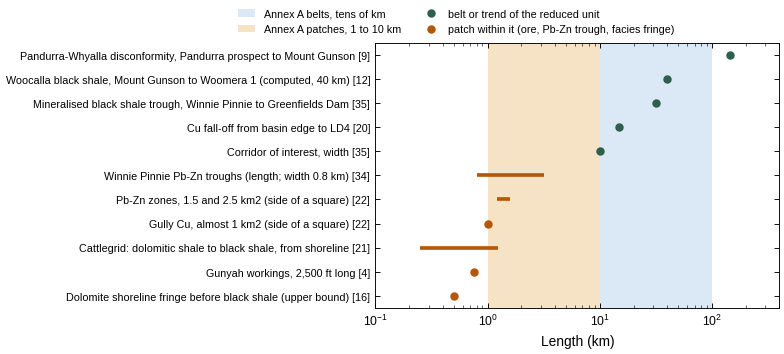

                                                            label  kind     lo     hi  row
Pandurra-Whyalla disconformity, Pandurra prospect to Mount Gunson  belt 145.00 145.00    9
Woocalla black shale, Mount Gunson to Woomera 1 (computed, 40 km)  belt  40.04  40.04   12
 Mineralised black shale trough, Winnie Pinnie to Greenfields Dam  belt  32.00  32.00   35
                               Cu fall-off from basin edge to LD4  belt  15.00  15.00   20
                                      Corridor of interest, width  belt  10.00  10.00   35
               Winnie Pinnie Pb-Zn troughs (length; width 0.8 km) patch   0.80   3.20   34
                  Pb-Zn zones, 1.5 and 2.5 km2 (side of a square) patch   1.22   1.58   22
                        Gully Cu, almost 1 km2 (side of a square) patch   1.00   1.00   22
       Cattlegrid: dolomitic shale to black shale, from shoreline patch   0.25   1.25   21
                                   Gunyah workings, 2,500 ft long patch   0.76   0.76    4

In [13]:
ML = pd.DataFrame([  # label, kind, lo, hi, dossier row
    ("Pandurra-Whyalla disconformity, Pandurra prospect to Mount Gunson", "belt", 145, 145, 9),
    (f"Woocalla black shale, Mount Gunson to Woomera 1 (computed, {d_gun_woo:.0f} km)", "belt", d_gun_woo, d_gun_woo, 12),
    ("Mineralised black shale trough, Winnie Pinnie to Greenfields Dam", "belt", 32, 32, 35),
    ("Cu fall-off from basin edge to LD4", "belt", 15, 15, 20),
    ("Corridor of interest, width", "belt", 10, 10, 35),
    ("Winnie Pinnie Pb-Zn troughs (length; width 0.8 km)", "patch", 0.8, 3.2, 34),
    ("Pb-Zn zones, 1.5 and 2.5 km2 (side of a square)", "patch", np.sqrt(1.5), np.sqrt(2.5), 22),
    ("Gully Cu, almost 1 km2 (side of a square)", "patch", 1.0, 1.0, 22),
    ("Cattlegrid: dolomitic shale to black shale, from shoreline", "patch", 0.25, 1.25, 21),
    ("Gunyah workings, 2,500 ft long", "patch", 0.76, 0.76, 4),
    ("Dolomite shoreline fringe before black shale (upper bound)", "patch", 0.5, 0.5, 16),
], columns=["label", "kind", "lo", "hi", "row"])
KC2 = {"belt": FAC_COL["reduced"], "patch": "#b35806"}
fig, ax = plt.subplots(figsize=(COL2, 3.3))
fig.subplots_adjust(left=0.47, right=0.98, top=0.87, bottom=0.14)
ax.axvspan(10, 100, color="#dbe8f5", lw=0, label="Annex A belts, tens of km")
ax.axvspan(1, 10, color="#f6e3c6", lw=0, label="Annex A patches, 1 to 10 km")
for i, r in ML.iterrows():
    if abs(r.hi - r.lo) < 1e-6: ax.plot(r.lo, i, "o", color=KC2[r.kind], ms=4.5)
    else: ax.plot([r.lo, r.hi], [i, i], color=KC2[r.kind], lw=2.4, solid_capstyle="butt")
ax.set_yticks(range(len(ML))); ax.set_yticklabels([f"{a} [{b}]" for a, b in zip(ML.label, ML.row)], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlim(0.1, 400); ax.set_xlabel("Length (km)")
for k, c in [("belt or trend of the reduced unit", KC2["belt"]), ("patch within it (ore, Pb-Zn trough, facies fringe)", KC2["patch"])]:
    ax.plot([], [], "o", color=c, ms=4.5, label=k)
ax.legend(loc="lower center", bbox_to_anchor=(0.2, 1.0), ncol=2, fontsize=FS_ANNOT)
fig.savefig(FIG / "wp4_L3_C3_mount_gunson_lengths.png", dpi=300)
plt.show()
print(ML.assign(lo=ML.lo.round(2), hi=ML.hi.round(2)).to_string(index=False))


### How to read this figure

Each row is one length from a pre-t0 Mount Gunson document; dots are single values, bars ranges. Dark green rows are the extent of the reduced unit or of the disconformity it sits on, brown rows the size of something inside it: an ore or Pb-Zn body, or a facies fringe. The blue band is the annex's belts of tens of km, the tan band its patches of 1 to 10 km. The belts sit in or above the blue band: 15 km for the fall-off of copper away from the basin edge, 32 km for the mineralised black-shale trough from Winnie Pinnie to Greenfields Dam, 40 km from Mount Gunson to Woomera 1, and 145 km along the Pandurra-Whyalla disconformity from the Pandurra prospect, where Mason (1967) took the same surface to control the copper. The patches sit at or below the lower end of the tan band: Pb-Zn troughs 0.8 to 3.2 km, zones of 1.5 to 2.5 km2 (1.2 to 1.6 km on a side), the Gully copper over almost 1 km2, the 1.25 km from shoreline dolomitic shale to black shale north of the Cattlegrid, and a dolomite fringe under 0.5 km wide. The local analog therefore supports tens of km for the belt and puts the patches at about 0.5 to 3 km, the low end of the annex range.


### Step C4. Presence and thickness of the reduced shale

The 1971 LD holes are the closest thing at t0 to an unbiased sample of the reduced unit: seven widely spaced holes from Oakden Hills to beyond Lake Dutton, all logged through to the Pandurra. Panel (a) shows the Woocalla shale each cut, with the two older bores Johns cites; panel (b) sets the LD presence fraction beside the estimates of Part A and the annex band.


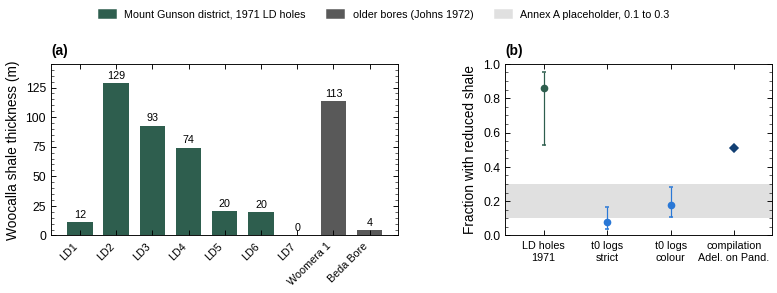

     site     t               src
      LD1  11.7     1971 LD holes
      LD2 128.7     1971 LD holes
      LD3  92.9     1971 LD holes
      LD4  74.3     1971 LD holes
      LD5  20.3     1971 LD holes
      LD6  20.0     1971 LD holes
      LD7   0.0     1971 LD holes
Woomera 1 113.4 water / oil bores
Beda Bore   4.3 water / oil bores
LD presence 6 of 7 = 0.86 (90% 0.53-0.95); thickness where present: median 47 m, range 12-129 m


In [14]:
k7, n7 = int(ld.woocalla_present.sum()), len(ld)
lo7, hi7 = stats.beta(1 + k7, 1 + n7 - k7).ppf([0.05, 0.95])
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.6), gridspec_kw=dict(width_ratios=[1.3, 1]))
fig.subplots_adjust(left=0.08, right=0.99, top=0.80, bottom=0.2, wspace=0.35)
ax = axes[0]
TH = pd.concat([ld[["hole", "woocalla_thickness_m"]].rename(columns={"hole": "site", "woocalla_thickness_m": "t"}).assign(src="1971 LD holes"),
                pd.DataFrame([("Woomera 1", 372 * FT_M, "water / oil bores"), ("Beda Bore", 14 * FT_M, "water / oil bores")],
                             columns=["site", "t", "src"])])
cols = [FAC_COL["reduced"] if s == "1971 LD holes" else "0.35" for s in TH.src]
ax.bar(range(len(TH)), TH.t, color=cols, width=0.7)
for i, t in enumerate(TH.t):
    ax.text(i, t + 2, f"{t:.0f}", ha="center", va="bottom", fontsize=FS_ANNOT)
ax.set_xticks(range(len(TH))); ax.set_xticklabels(TH.site, rotation=45, ha="right", fontsize=FS_ANNOT)
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylabel("Woocalla shale thickness (m)"); ax.set_ylim(0, 145)
ax = axes[1]
ax.axhspan(0.1, 0.3, color="0.88", lw=0)
EST = [("LD holes\n1971", k7 / n7, lo7, hi7, FAC_COL["reduced"]),
       ("t0 logs\nstrict", s20.p, s20.lo90, s20.hi90, PIECE_COL[1]),
       ("t0 logs\ncolour", p20.p, p20.lo90, p20.hi90, PIECE_COL[1])]
for j, (lab, p, lo, hi, c) in enumerate(EST):
    ax.errorbar(j, p, yerr=[[p - lo], [hi - p]], fmt="o", ms=4, color=c, lw=0.8, capsize=1.5)
ax.plot(3, pad, "D", ms=4, color="#123f73")
ax.set_xticks(range(4)); ax.set_xticklabels([e[0] for e in EST] + ["compilation\nAdel. on Pand."], fontsize=FS_ANNOT)
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(0, 1.0); ax.set_xlim(-0.6, 3.6)
ax.set_ylabel("Fraction with reduced shale")
panel_labels(axes)
h = [plt.Rectangle((0, 0), 1, 1, color=FAC_COL["reduced"], label="Mount Gunson district, 1971 LD holes"),
     plt.Rectangle((0, 0), 1, 1, color="0.35", label="older bores (Johns 1972)"),
     plt.Rectangle((0, 0), 1, 1, color="0.88", label="Annex A placeholder, 0.1 to 0.3")]
fig.legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=FS_ANNOT)
fig.savefig(FIG / "wp4_L3_C4_mount_gunson_presence.png", dpi=300)
plt.show()
print(TH.round(1).to_string(index=False))
print(f"LD presence {k7} of {n7} = {k7/n7:.2f} (90% {lo7:.2f}-{hi7:.2f}); thickness where present: median "
      f"{ld.loc[ld.woocalla_present, 'woocalla_thickness_m'].median():.0f} m, range "
      f"{ld.loc[ld.woocalla_present, 'woocalla_thickness_m'].min():.0f}-{ld.loc[ld.woocalla_present, 'woocalla_thickness_m'].max():.0f} m")


### How to read this figure

In (a) each bar is the Woocalla black or dolomitic shale thickness in one hole: 12 to 129 m in six of the seven 1971 LD holes (median 47 m) and none in LD7, with Woomera 1 (113 m) and Beda Bore (4 m) in grey. In (b) each mark is a fraction of holes with reduced shale above the Pandurra, with a 90% interval: the LD holes give 6 of 7, 0.86 (0.53 to 0.95); the pre-t0 lithology logs of Part A give 0.08 (strict) and 0.18 (colour) within 20 m of basement; the later compilation gives 0.51 for Adelaidean rock on Pandurra. The grey band is the annex's 0.1 to 0.3. What the reader should see is that where the Stuart Shelf sequence is actually present over the Pandurra, as in the Mount Gunson basin, the reduced unit is there in most holes and is tens of metres thick; the low Part A numbers come from holes that reached basement under young cover. The LD sample is small and sited inside a known basin, so 0.86 is an upper figure for the shelf, not a marginal probability for the target.


### Step C5. Grade and tonnage as known before t0 (for Level 4)

Not a Level 3 parameter, but the dossier holds every grade and tonnage figure a t0 reader could find for Mount Gunson, and Level 4 will need them. They are drawn here once so the Level 4 notebook can cite this step.


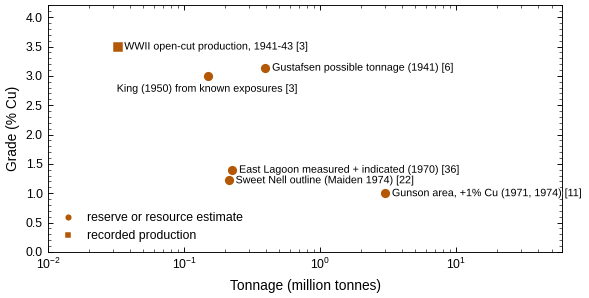

                                  label    Mt   cu  row       kind  Cu_kt
      Gustafsen possible tonnage (1941) 0.395 3.14    6   estimate 12.403
       King (1950) from known exposures 0.150 3.00    3   estimate  4.500
      WWII open-cut production, 1941-43 0.032 3.50    3 production  1.133
       Sweet Nell outline (Maiden 1974) 0.213 1.22   22   estimate  2.599
East Lagoon measured + indicated (1970) 0.226 1.40   36   estimate  3.162
       Gunson area, +1% Cu (1971, 1974) 3.000 1.00   11   estimate 30.000


In [15]:
GT = pd.DataFrame([  # label, Mt, % Cu, dossier row, kind
    ("Gustafsen possible tonnage (1941)", 0.395, 3.14, 6, "estimate"),
    ("King (1950) from known exposures", 0.150, 3.0, 3, "estimate"),
    ("WWII open-cut production, 1941-43", 0.03238, 3.5, 3, "production"),
    ("Sweet Nell outline (Maiden 1974)", 0.213, 1.22, 22, "estimate"),
    ("East Lagoon measured + indicated (1970)", 0.249 * 0.907, 1.40, 36, "estimate"),
    ("Gunson area, +1% Cu (1971, 1974)", 3.0, 1.0, 11, "estimate"),
], columns=["label", "Mt", "cu", "row", "kind"])
fig, ax = plt.subplots(figsize=(COL15, 2.8))
fig.subplots_adjust(left=0.12, right=0.97, top=0.97, bottom=0.17)
for r in GT.itertuples():
    ax.plot(r.Mt, r.cu, "o" if r.kind == "estimate" else "s", color="#b35806", ms=5)
    left = r.label.startswith("King")
    ax.text(r.Mt if left else r.Mt * 1.12, r.cu - (0.22 if left else 0), f"{r.label} [{r.row}]", va="center",
            ha="center" if left else "left", fontsize=FS_ANNOT, path_effects=HALO)
ax.set_xscale("log"); ax.set_xlim(0.01, 60); ax.set_ylim(0, 4.2)
ax.set_xlabel("Tonnage (million tonnes)"); ax.set_ylabel("Grade (% Cu)")
ax.plot([], [], "o", color="#b35806", label="reserve or resource estimate"); ax.plot([], [], "s", color="#b35806", label="recorded production")
ax.legend(loc="lower left")
fig.savefig(FIG / "wp4_L3_C5_mount_gunson_grade_tonnage.png", dpi=300)
plt.show()
GT["Cu_kt"] = GT.Mt * GT.cu * 10
print(GT.round(3).to_string(index=False))


### How to read this figure

Each mark is one tonnage and grade stated before t0, on a logarithmic tonnage axis; circles are reserve or resource estimates, the square is recorded production, and the number in brackets is the dossier row. The figures span two groups: small high-grade bodies of 0.03 to 0.4 Mt at 3 to 3.5% Cu (the 1941-43 production, King's 1950 expectation, Gustafsen's 1941 possible tonnage) and larger low-grade figures of 0.2 to 3 Mt at 1 to 1.4% Cu (East Lagoon in April 1970, Sweet Nell in 1974, and the 3 Mt of +1% Cu given for the Gunson area in 1971 and 1974). The largest, 3 Mt at 1%, is about 30 kt of contained copper. What the reader should see is that the t0 analog is a district of small tabular bodies, up to about 5 m thick, not a single large deposit.


### Verdict on Mount Gunson

The analog WMC named is well documented before t0: 37 statements from 13 open-file documents, 36 of them dated before the grant. They add three things to Level 3. First, presence: where the Stuart Shelf sequence lies on the Pandurra, the Woocalla black or dolomitic shale is there in 6 of 7 widely spaced holes, 12 to 129 m thick, and Woomera 1, 82 km from the deposit, cut 113 m of it. Second, lengths: the reduced unit and the disconformity it rests on are traced for 15 to 145 km, and the patches inside it (ore, Pb-Zn troughs, facies fringes) are 0.5 to 3 km, at the low end of the annex's 1 to 10 km. Third, the rule the reports agree on: copper on the Pandurra unconformity where the reduced shale meets an oxidised or shoreline facies, in depressions of the old surface, beside a basement high, with basic dykes proposed as a metal source by 1972. The dossier also holds the grade and tonnage figures Level 4 needs. What it cannot supply is the key factor for the target itself: whether the shelf sequence reaches the basement contact 115 km to the north, where no t0 hole reached it.


## Part D. The Level 3 rows against what the pieces cite

One parameter, one row. Panel (a) is the marginal presence, (b) the belt length, (c) the patch length, each against the annex's placeholder range. The cell also writes the citation rows to `03_results/wp4_prior/wp4_L3_parameter_rows.csv`.


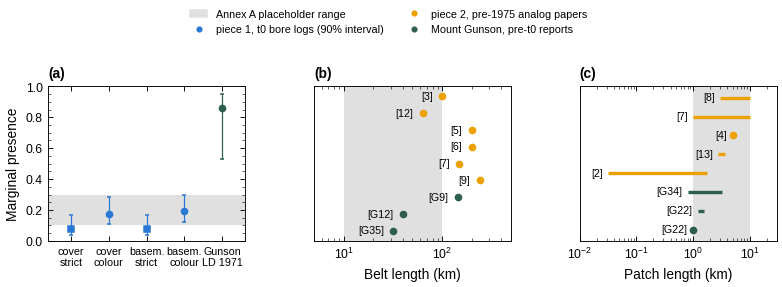

                                      parameter                            annex_value                                                                                                           in_state_value                                                                                                                                                                                     source                                    status
reduced-facies marginal presence at the contact                     0.1 to 0.3 [CHECK]       0.08 strict (90% 0.04-0.17) to 0.18 by colour (90% 0.11-0.28), 4 and 9 of 51 holes, pre-t0 litho logs, 20 m window               SA Geodata litho export (logs dated before t0); contact from strat compilation; Mount Gunson 1971 LD holes 6 of 7 (RB 72/00189); Woomera 1 113 m dark-grey shale on Pandurra                      in state, translated
                     reduced-facies belt length                     tens of km [CHECK] reduced horizons continuous for >= 64 k

In [16]:
pc = P[P["class"].isin(["reductant word", "reduced"]) & (P.W_m == 20)]
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.6))
fig.subplots_adjust(left=0.07, right=0.99, top=0.74, bottom=0.2, wspace=0.35)
ax = axes[0]
ax.axhspan(0.1, 0.3, color="0.88", lw=0)
for j, (i, r) in enumerate(pc.iterrows()):
    ax.errorbar(j, r.p, yerr=[[r.p - r.lo90], [r.hi90 - r.p]], fmt="s" if r["class"] == "reductant word" else "o",
                ms=4, color=PIECE_COL[1], lw=0.8, capsize=1.5)
ax.errorbar(len(pc), k7 / n7, yerr=[[k7 / n7 - lo7], [hi7 - k7 / n7]], fmt="o", ms=4, color=FAC_COL["reduced"], lw=0.8, capsize=1.5)
ax.set_xticks(range(len(pc) + 1))
ax.set_xticklabels([f"{'cover' if 'cover' in a else 'basem.'}\n{'strict' if c == 'reductant word' else 'colour'}"
                    for a, c in zip(pc.reading, pc["class"])] + ["Gunson\nLD 1971"], fontsize=FS_ANNOT)
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(0, 1.0); ax.set_xlim(-0.6, len(pc) + 0.6)
ax.set_ylabel("Marginal presence")
for ax, band, sel, xl in [(axes[1], (10, 100), ["reduced horizon", "belt of ore bodies"], "Belt length (km)"),
                          (axes[2], (1, 10), ["ore patch"], "Patch length (km)")]:
    ax.axvspan(*band, color="0.88", lw=0)
    s = L[L.kind.isin(sel)].assign(src="analog")
    mgsel = ML[(ML.kind == ("belt" if "reduced horizon" in sel else "patch")) & ML.row.isin([9, 12, 35, 34, 22] if "reduced horizon" in sel else [34, 22])]
    mgsel = mgsel[~mgsel.label.str.contains("Corridor|fall-off", regex=True)].assign(src="gunson")
    s = pd.concat([s, mgsel[["label", "kind", "lo", "hi", "row"]].assign(src="gunson")]).reset_index(drop=True)
    for i, r in s.iterrows():
        c = PIECE_COL[2] if r.src == "analog" else FAC_COL["reduced"]
        if r.lo == r.hi: ax.plot(r.lo, i, "o", color=c, ms=4)
        else: ax.plot([r.lo, r.hi], [i, i], color=c, lw=2.2, solid_capstyle="butt")
        ax.text(r.lo / 1.25, i, f"[{r.row}]" if r.src == "analog" else f"[G{r.row}]", ha="right", va="center", fontsize=FS_ANNOT)
    ax.set_xscale("log"); ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.set_ylim(len(s) - 0.4, -0.6); ax.set_xlabel(xl)
axes[1].set_xlim(5, 500); axes[2].set_xlim(0.01, 30)
panel_labels(axes, ("(a)", "(b)", "(c)"))
h = [plt.Rectangle((0, 0), 1, 1, color="0.88", label="Annex A placeholder range"),
     plt.Line2D([], [], marker="o", ls="", color=PIECE_COL[1], label="piece 1, t0 bore logs (90% interval)"),
     plt.Line2D([], [], marker="o", ls="", color=PIECE_COL[2], label="piece 2, pre-1975 analog papers"),
     plt.Line2D([], [], marker="o", ls="", color=FAC_COL["reduced"], label="Mount Gunson, pre-t0 reports")]
fig.legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2, fontsize=FS_ANNOT)
fig.savefig(FIG / "wp4_L3_D1_parameters.png", dpi=300)
plt.show()
rows = pd.DataFrame([
    ("reduced-facies marginal presence at the contact", "0.1 to 0.3 [CHECK]",
     f"{s20.p:.2f} strict (90% {s20.lo90:.2f}-{s20.hi90:.2f}) to {p20.p:.2f} by colour (90% {p20.lo90:.2f}-{p20.hi90:.2f}), "
     f"{int(s20.k)} and {int(p20.k)} of {int(p20.n)} holes, pre-t0 litho logs, 20 m window",
     "SA Geodata litho export (logs dated before t0); contact from strat compilation; Mount Gunson 1971 LD holes "
     f"{k7} of {n7} (RB 72/00189); Woomera 1 113 m dark-grey shale on Pandurra", "in state, translated"),
    ("reduced-facies belt length", "tens of km [CHECK]",
     f"reduced horizons continuous for >= 64 km (White Pine) to ~{L[L.kind=='reduced horizon'].lo.max():.0f} km (Copperbelt Ore Shale); "
     f"mineralised belts {L[L.kind=='belt of ore bodies'].lo.min():.0f} to {L[L.kind=='belt of ore bodies'].hi.max():.0f} km",
     "Binda and Mulgrew 1974; White and Wright 1954; Brown 1974; Johnson 1974; Kirkham 1974; Mount Gunson: Mason 1967 (145 km), "
     "Pacminex 1973 (Gunson to Woomera 1), Johns 1972 (32 km trough)", "in state, analog + local"),
    ("reduced-facies patch length", "1 to 10 km [CHECK]",
     "1 to 10 km for ore patches, not reduced-facies patches; Mansfeld ore areas to ~1.7 km",
     "Johnson 1974; Binda and Mulgrew 1974; White and Wright 1954; Rentzsch 1974; Mount Gunson: Johns 1972 (troughs 1.6-3.2 km), "
     "Maiden 1974 (Pb-Zn zones 1.5-2.5 km2, dolomite fringe < 0.5 km)", "in state, analog + local; meaning differs"),
    ("vertical position of the redox front", "(not in annex)",
     "White Pine Cu-Fe fringe a single blanket 6 to 15 m above the base of the grey Nonesuch, red beds below",
     "Brown 1971; White and Wright 1954", "in state, analog"),
    ("placement of reduced facies", "at and near the basement-cover contact",
     "transgressive palaeolittoral sediments close to unconformities; highs of block-faulted basement",
     "Rowlands 1974; Binda and Mulgrew 1974", "in state, analog (local)"),
], columns=["parameter", "annex_value", "in_state_value", "source", "status"])
rows.to_csv(TAB / "wp4_L3_parameter_rows.csv", index=False)
print(rows.to_string(index=False))


### How to read this figure

Each panel is one Annex A Level 3 parameter; the grey band is the annex's placeholder. Blue marks come from the t0 bore logs of Part A, orange from the pre-1975 analog papers of Part B, and dark green from the Mount Gunson reports of Part C (labels G plus the dossier row). In (a), marginal presence, the Part A logs give 0.08 (strict) to 0.18 to 0.19 (colour), whichever way the Pandurra is read, and the Mount Gunson LD holes give 0.86 where the shelf sequence is present. In (b) the belts run from 32 km (Mount Gunson trough) and at least 64 km (White Pine) to 100 to 240 km. In (c) the analog ore patches sit in the 1 to 10 km band and the Mount Gunson patches at about 1 to 3 km, with the Kupferschiefer ore areas smaller. Read together: the marginal presence depends on whether the shelf sequence is present at the target, the belt length should run from a few tens to a few hundred km, and the patch length is supported for ore-bearing patches, at the lower end of 1 to 10 km.


## Verdict on Level 3

Both basis pieces are on disk and in state. Of the analog texts the annex names, the two White Pine papers in Economic Geology are on disk; Mendelsohn (1961) and Ensign et al. (1968) are print only and are carried through in-state stand-ins. Mount Gunson, the analog WMC itself named, is documented by 13 open-file reports dated 1941 to October 1974.

For piece 1, the t0 logs are the SA Geodata lithology logs, 708 holes logged before t0, not the stratigraphic compilation. Near basement they give a reduced-facies presence of 0.08 (strict) to 0.18 (colour), but in young cover on the craton margins; only one or two pre-t0 logs cross the Adelaidean-on-basement contact. Where that sequence is present, the Mount Gunson record says the reduced Woocalla shale is too: 6 of 7 LD holes, 12 to 129 m, and 113 m in Woomera 1, 82 km from the deposit.

For piece 2, the pre-1975 analog papers set reduced hosts as belts from at least 64 km (White Pine) to 100 to 240 km, ore patches of 1 to 10 km, one ore-free gap of 400 m over a basement high, ore occupancy of 0.002 (Kupferschiefer) to 0.3 (Permian shales), and a redox front 6 to 15 m above the base of the reduced unit (White Pine). Mount Gunson gives the same structure at shelf scale: belts of 15 to 145 km and patches of 0.5 to 3 km.

For the citation table (written to `03_results/wp4_prior/wp4_L3_parameter_rows.csv`):
- **Marginal presence:** write it as two factors. The first is the chance that the Stuart Shelf sequence reaches the target contact, a Level 1 question. The second is the chance that its basal unit is reduced where present, about 0.5 (compilation) to 0.86 (LD holes), cited to RB 72/00189 and Woomera 1. The Part A logs (0.08 to 0.18) stand as a check on young cover only.
- **Belt length:** cite Binda and Mulgrew 1974, White and Wright 1954, Brown 1974 and, locally, Mason 1967 and Johns 1972, and move the range to a few tens to a few hundred km.
- **Patch length:** cite Johnson, Binda and Mulgrew, Rentzsch, White and Wright, and Johns 1972 and Maiden 1974, reworded to "ore patches within the reduced belt" at about 0.5 to 5 km.
- **Placement:** cite Rowlands 1974, Johns 1972 and Maiden 1974: on the Pandurra unconformity, in depressions of the old surface, beside a basement high.

Rulings to add to the list: whether a reduced class read from colour words is acceptable evidence; whether the compilation's "one half" for Adelaidean on Pandurra may be carried as a translation although written after t0; how to treat the Pacminex genesis text signed March 1975 but issued July 1976; and, from Level 1, whether the Pandurra counts as cover or basement.
